## **Exploratory Data Analysis of an Image Dataset**

#### **Dataset Contents**

The dataset itself was constructed using the following datasets:
* [Nature Dataset](https://huggingface.co/datasets/mertcobanov/nature-dataset) - Nature photos 
* [European Cities 1M dataset](http://image.ntua.gr/iva/datasets/ec1m/index.html) - Town pictures
* [CelebA Dataset](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset) - Peoples' faces

#### **The Process of Data Collection**

* The [Nature Dataset](https://huggingface.co/datasets/mertcobanov/nature-dataset) was fully included (`50.000` images).

* We downloaded `50.000` images at random by accessing the provided links [European Cities 1M dataset](http://image.ntua.gr/iva/datasets/ec1m/index.html). There exists [European Cities 50K dataset](http://image.ntua.gr/iva/datasets/ec50k/index.html) version. However, some links were not achievable, thus we used its bigger version.

* [CelebA Dataset](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset) — `50.000` images were randomly sampled.

#### **Dataset Format**

The `150.000` images (`.jpg` format) are located in the *images* folder, the CSV file contains `filename` and `category` columns. There are `3` categories: `nature`, `city`, `faces`.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import hashlib
import os
from collections import defaultdict

import cv2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import warnings

warnings.filterwarnings('ignore')

image_dir = 'dataset/images'

sns.set_palette(sns.color_palette('Set2'))

In [4]:
df = pd.read_csv('dataset/dataset.csv')
df.head()

,filename,category
0,000001.jpg,faces
1,000002.jpg,faces
2,000003.jpg,faces
3,000004.jpg,faces
4,000005.jpg,faces


## **Dataset Overview**

In [5]:
df['index'] = df.groupby('category').cumcount()
pivot_df = df.pivot(index='index', columns='category', values='filename')

pivot_df.columns.name = None
pivot_df.reset_index(drop=True, inplace=True)
df = df.drop(columns=['index'], axis=1)

pivot_df

,city,faces,nature
0,050001.jpg,000001.jpg,100001.jpg
1,050002.jpg,000002.jpg,100002.jpg
2,050003.jpg,000003.jpg,100003.jpg
3,050004.jpg,000004.jpg,100004.jpg
4,050005.jpg,000005.jpg,100005.jpg
...,...,...,...
49995,099996.jpg,049996.jpg,149996.jpg
49996,099997.jpg,049997.jpg,149997.jpg
49997,099998.jpg,049998.jpg,149998.jpg
49998,099999.jpg,049999.jpg,149999.jpg


Let's have a look at the images from each category

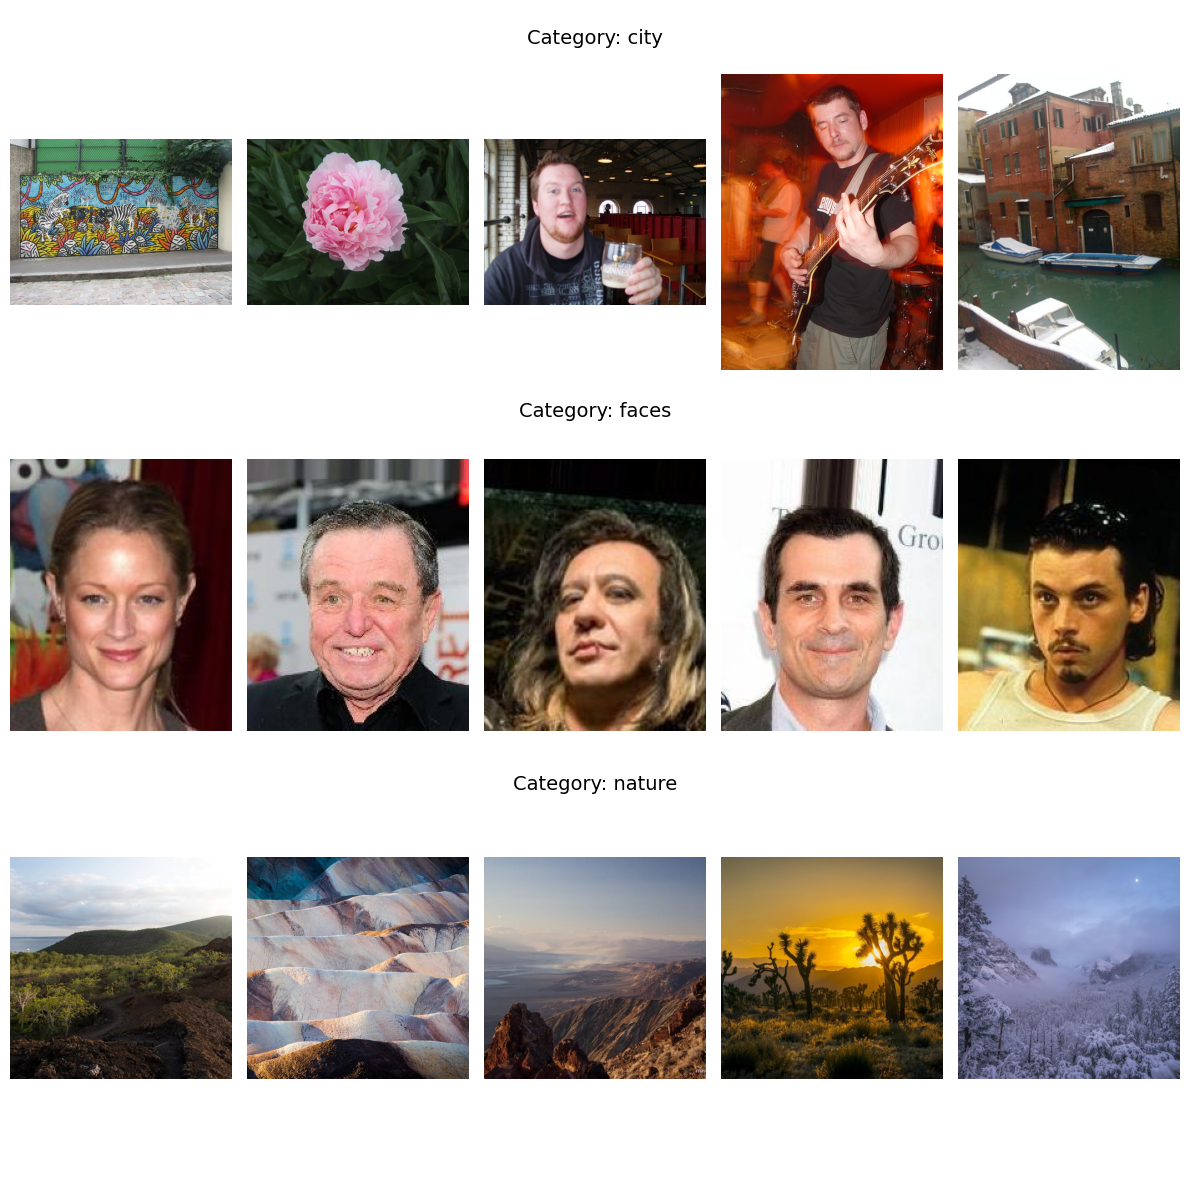

In [6]:
image_dir = 'dataset/images'
categories = ['city', 'faces', 'nature']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))

for ax_index, category in enumerate(categories):
    selected_files = np.random.choice(pivot_df[category].dropna().tolist(), size=5, replace=False)
    
    for index, file in enumerate(selected_files):
        img = plt.imread(f'{image_dir}/{file}')
        
        sub_ax = fig.add_subplot(len(categories), 5, 
                                ax_index * 5 + index + 1)
        
        sub_ax.imshow(img)
        sub_ax.axis('off')

    axes[ax_index].axis('off')
    axes[ax_index].set_title(f'Category: {category}', fontsize=14, y=0.9)

plt.tight_layout()
plt.show()

Total initial amount of images for each group

In [7]:
df.category.value_counts().reset_index()

,category,count
0,faces,50000
1,city,50000
2,nature,50000


## **Preprocessing**

### **1. Duplicates Processing**

In [8]:
hash_groups = defaultdict(list)

for idx, row in df.iterrows():
    img_path = os.path.join(image_dir, row['filename'])
    
    with open(img_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    
    hash_groups[file_hash].append({
        'filename': row['filename'],
        'category': row['category']
    })
        

duplicates = {hash_val: group for hash_val, group in hash_groups.items() if len(group) > 1}

Total amount of duplicates for each category

In [9]:
categories = set()
amount = 0
for hash_val, group in duplicates.items():
    for dup in group:
        categories.add(dup['category'])
    amount += len(group) - 1

print(f'Duplicates amount: {amount}')
print(f'Categories:  {categories}')

Duplicates amount: 56
Categories:  {'nature', 'faces'}


Remove the duplicates

In [10]:
to_remove = []
for hash_val, group in duplicates.items():
    group.pop()
    filenames = [item['filename'] for item in group]
    to_remove.extend(filenames)

df = df[~df['filename'].isin(to_remove)].reset_index(drop=True)

Total amount of images for each group after duplicates deletion

In [11]:
df.category.value_counts().reset_index()

,category,count
0,city,50000
1,faces,49996
2,nature,49948


### **2. Grayscale Images Processing**

Since one of the given tasks is image coloring, it is necessary to remove any grayscale image that occurs in the dataset, as we will not have a colorful label for training or evaluation further.

Amount of grayscale images by categories:

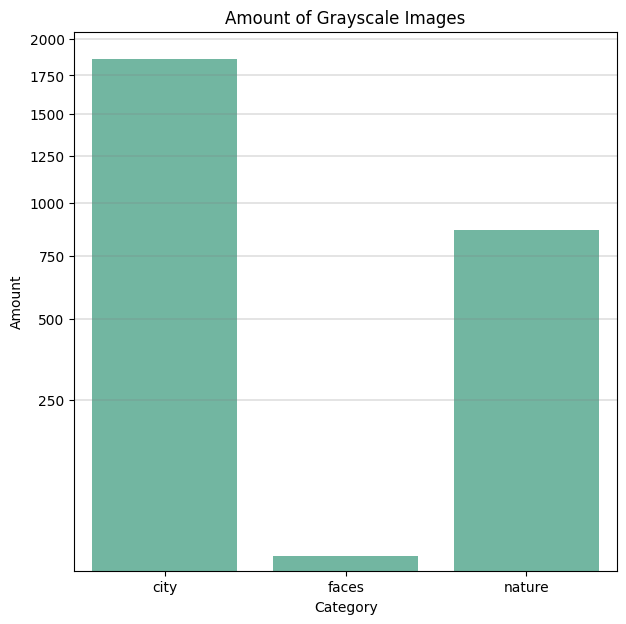

In [13]:
def is_grayscale(image_path):
    img = cv2.imread(image_path)
    if img.shape[2] == 3:
        b, g, r = cv2.split(img)
        if np.array_equal(b, g) and np.array_equal(b, r):
            return True
        else:
            return False
    else:
        return True
    

df['is_grayscale'] = df.apply(
    lambda row: is_grayscale(f"{image_dir}/{row['filename']}"), 
    axis=1
)

fig, ax = plt.subplots(figsize=(7, 7))

ax.grid(color='grey', linewidth=0.3)
ax.set_yscale('function', functions=(np.sqrt, np.square))
sns.barplot(x=df.groupby('category').is_grayscale.agg('sum').index, y=df.groupby('category').is_grayscale.agg('sum').values)
ax.set_title('Amount of Grayscale Images')
ax.set_xlabel('Category')
ax.set_ylabel('Amount')

plt.show()

Total amount of the grayscale images:

In [14]:
print(df.is_grayscale.sum())

2743


Total amount of images in the dataset after removing the grayscale images:

In [15]:
df = df[df['is_grayscale'] != True]
print(df.shape[0])

147201


## **Dataset Analysis**

### **1. Width and Height Overview**

In [16]:
# complement the dataset with the images width and height columns

def get_resolution(filename: str):
    img = Image.open(f'{image_dir}/{filename}')
    return img.width, img.height

res = df['filename'].apply(lambda filename: get_resolution(filename))
df['width'] = res.apply(lambda x: x[0])
df['height'] = res.apply(lambda x: x[1])

df.head()

,filename,category,is_grayscale,width,height
0,000001.jpg,faces,False,178,218
1,000002.jpg,faces,False,178,218
2,000003.jpg,faces,False,178,218
3,000004.jpg,faces,False,178,218
4,000005.jpg,faces,False,178,218


The images width and height distribution:

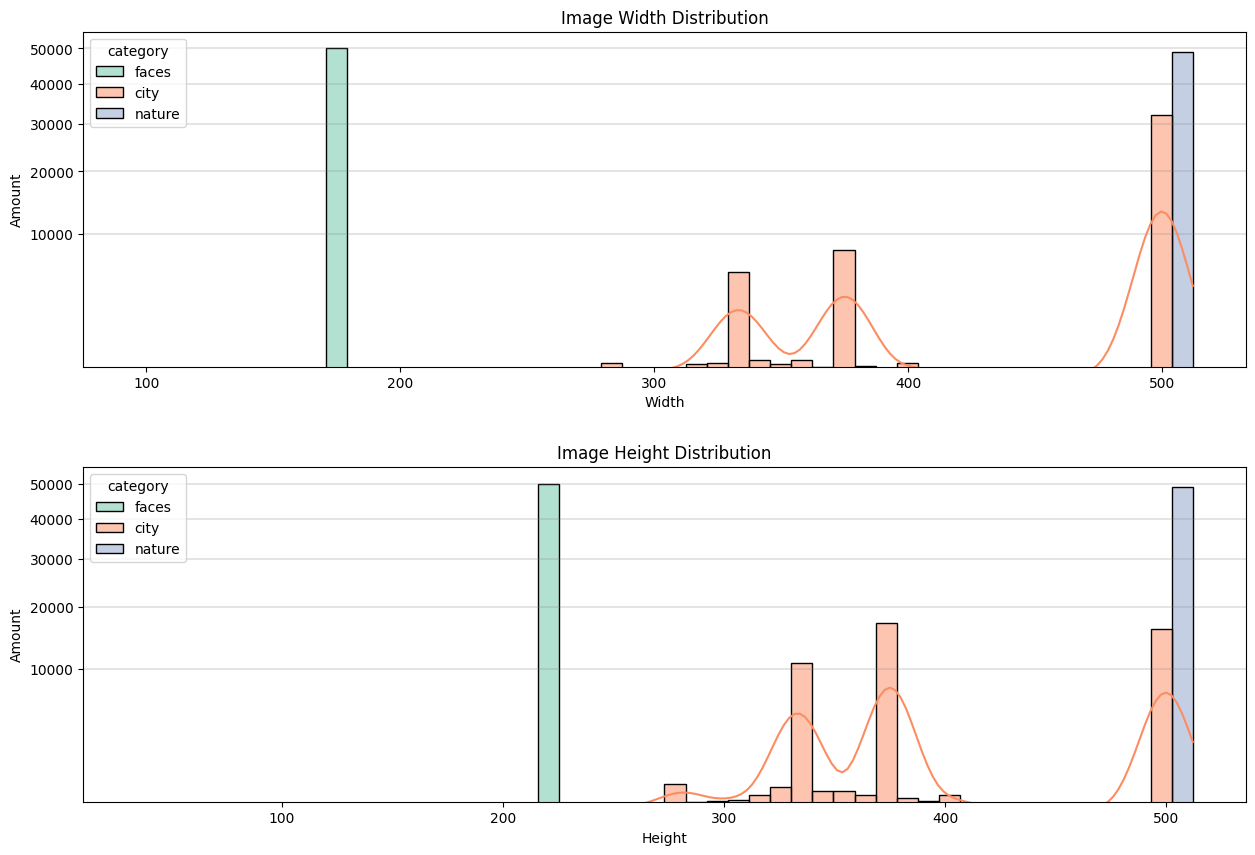

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# set scale
axes[0].set_yscale('function', functions=(np.sqrt, np.square))
axes[1].set_yscale('function', functions=(np.sqrt, np.square))


# turn on the grid
axes[0].grid(axis='y', color='grey', linewidth=0.3)
axes[1].grid(axis='y', color='grey', linewidth=0.3)


# draw plots
sns.histplot(data=df, x='width', hue='category', bins=50, kde=True, ax=axes[0])
sns.histplot(data=df, x='height', hue='category', bins=50, kde=True, ax=axes[1])


# set titles
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Amount')

axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Amount')


fig.subplots_adjust(hspace=0.3)

plt.show()


The resolution of the images by the categories:

* `faces` — `178 x 218`,
* `nature` — `512 x 512`,
* `city` — the resolution varies

The scatter plot (`width vs height`) and the aspect ratio distribution:

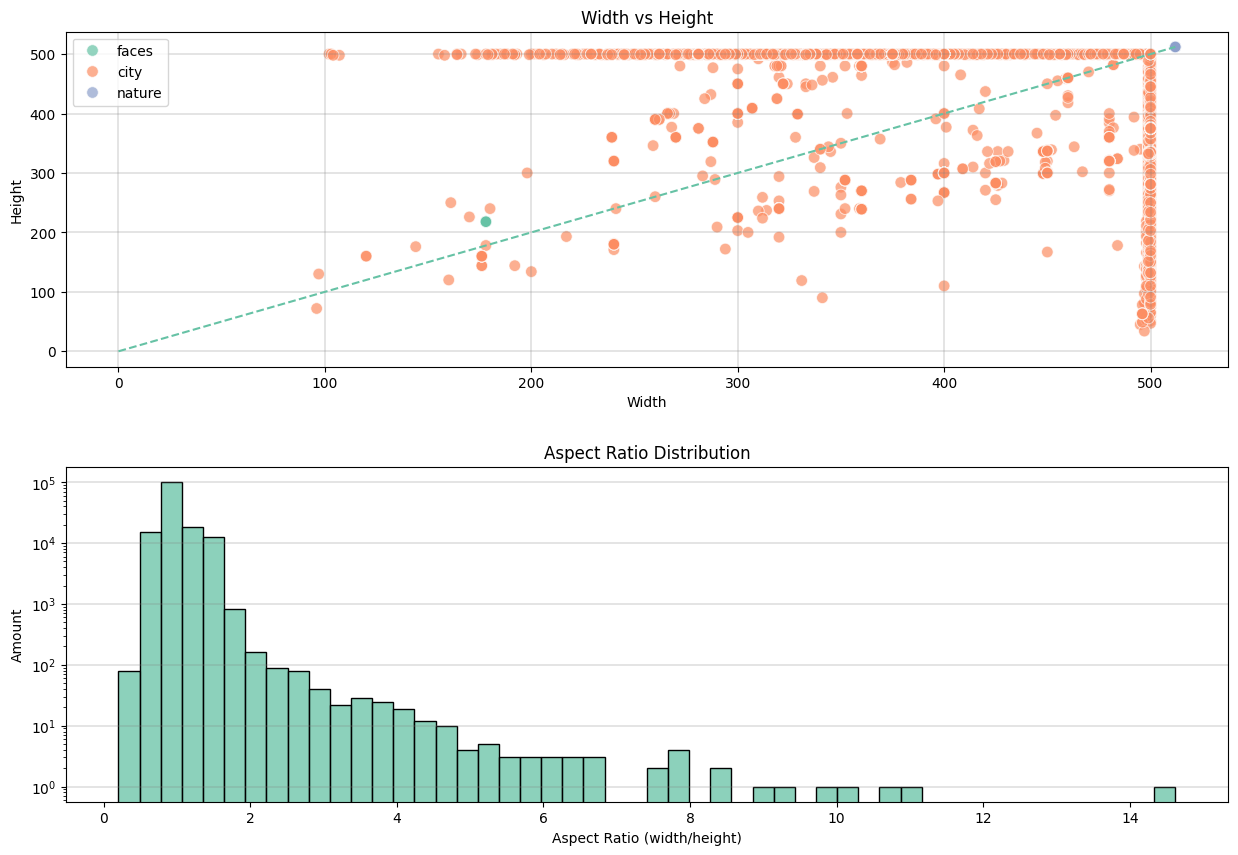

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
df['aspect_ratio'] = df['width'] / df['height']

# set scale
axes[1].set_yscale('log')


# turn on the grid
axes[0].grid(color='grey', linewidth=0.3)
axes[1].grid(axis='y', color='grey', linewidth=0.3)


# draw plots
sns.scatterplot(data=df, x='width', y='height', s=70, alpha=0.7, hue='category', ax=axes[0])

sns.histplot(data=df, x='aspect_ratio', bins=50, kde=False, ax=axes[1])
sns.lineplot(x=[0, df['width'].max()], y=[0, df['height'].max()], ax=axes[0], linestyle='--')


# set titles
axes[0].set_title('Width vs Height')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Height')

axes[1].set_title('Aspect Ratio Distribution')
axes[1].set_xlabel('Aspect Ratio (width/height)')
axes[1].set_ylabel('Amount')


fig.subplots_adjust(hspace=0.3)

plt.show()

The amount of images with aspect ratio higher than `6`:

In [43]:
df[df['aspect_ratio'] > 6].shape[0]

24

It was decided to remove these images as extreme cases:

In [ ]:
df = df[df['aspect_ratio'] <= 6]

The total amount of images:

In [45]:
df.shape[0]

147177

The amount of images divided by categories

In [48]:
df.category.value_counts().reset_index()

,category,count
0,faces,49985
1,nature,49080
2,city,48112


### **2. Splitting Images by Categories Using ResNet and PCA**

The initial image categorization is based on the sources. We decided to know can the images be well-splitted into 3 clusters based on their features. It will help to evaluate the chosen data sources.

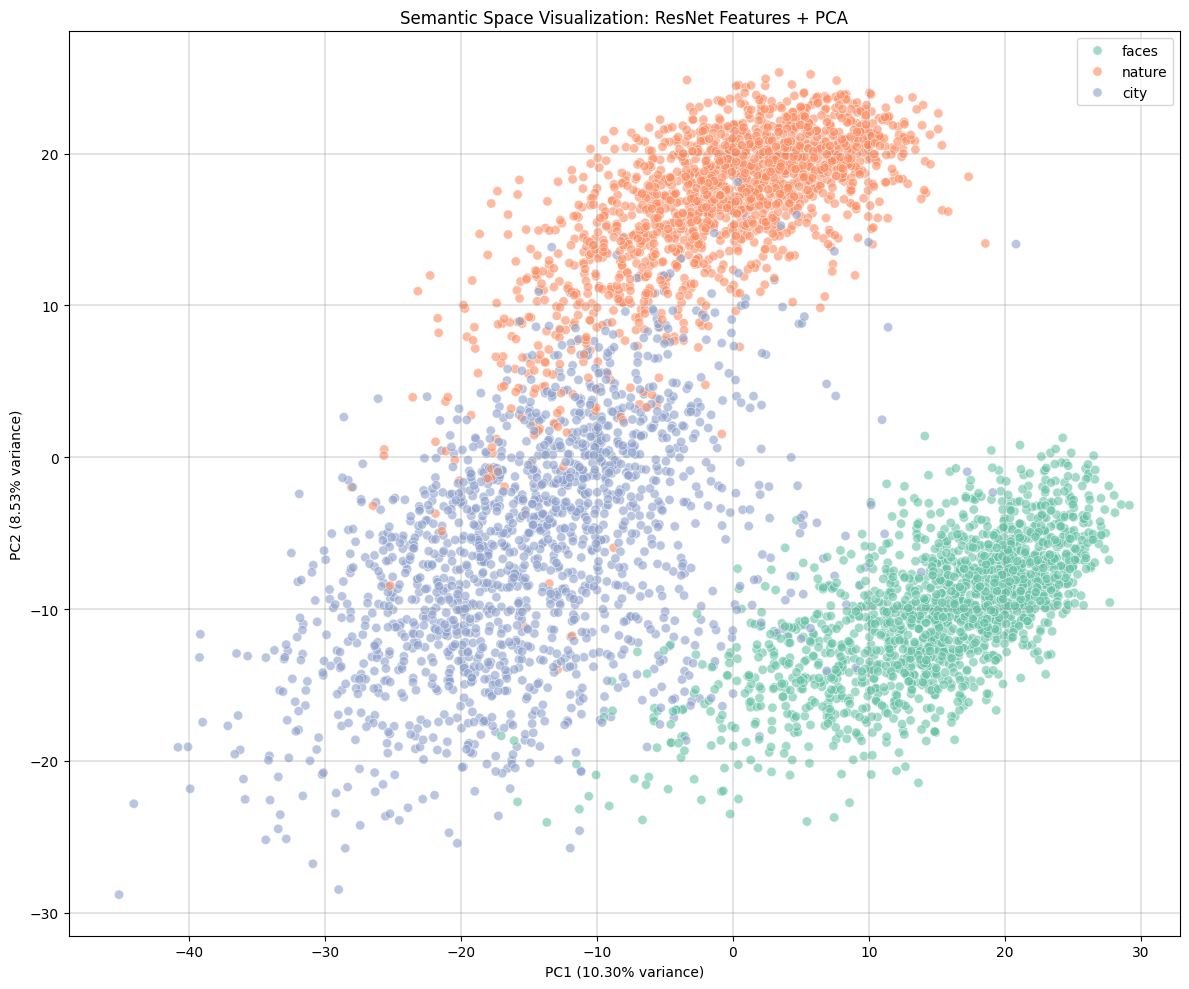

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*(list(model.children())[:-1]))

model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features_batch(df, batch_size=64):
    features = []
    indices = []
    
    for i in range(0, len(df), batch_size):
        batch_df = df.iloc[i:i+batch_size]
        batch_features = []
        batch_indices = []
        
        for idx, row in batch_df.iterrows():
            image = Image.open(f'{image_dir}/{row['filename']}').convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            with torch.no_grad():
                feature = model(image_tensor)
            batch_features.append(feature.cpu().squeeze().numpy())
            batch_indices.append(idx)
        
        if batch_features:
            features.extend(batch_features)
            indices.extend(batch_indices)
    
    return np.array(features), indices

sample_df = df.sample(5000)

features, indices = extract_features_batch(sample_df)

valid_df = df.loc[indices]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_components = pca.fit_transform(features_scaled)

fig, ax = plt.subplots(figsize=(12, 10))

ax.grid(color='grey', linewidth=0.3)

pca_df = pd.DataFrame({
    'pc_1': pca_components[:, 0],
    'pc_2': pca_components[:, 1],
    'category': valid_df['category']
})

sns.scatterplot(data=pca_df, x='pc_1', y='pc_2', s=45, hue='category',
                alpha=0.6, ax=ax)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Semantic Space Visualization: ResNet Features + PCA')
plt.legend()
plt.tight_layout()
plt.show()

The first two main components together explain `~18.83%` of the total variance of the feature space extracted by `ResNet`.

Based on this sample `(5000 images)` it can be observed that the `faces` and `nature` categories are well divisible related to each other. However, the `city` category is moderately mixed with these groups that shows the similar patterns occurrences (the `city` group is most similar to `nature`).

Based on that, we concluded that the division by categories is acceptable for the models.

### **2. Brightness Overview**

The brightness distribution is analyzed to identify potential data bias, which can significantly affect the processes of coloring and restoring images.

Let's construct `3` plots for the `mean brightness distribution`:

1. The bar plot of mean brightness distribution across the whole dataset
2. The KDE plot of mean brightness distribution within the categories
3. The violin plot of mean brightness distribution within the categories

In [20]:
brightness_metrics = []

for _, row in df.iterrows():
    img_path = f"{image_dir}/{row['filename']}"
    img = cv2.imread(img_path)
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    brightness_metrics.append({
        'filename': row['filename'],
        'category': row['category'],
        'mean_brightness': np.mean(gray),
        'std_brightness': np.std(gray),
        'median_brightness': np.median(gray),
        'min_brightness': np.min(gray),
        'max_brightness': np.max(gray),
        'brightness_range': np.ptp(gray)
    })

brightness_df = pd.DataFrame(brightness_metrics)

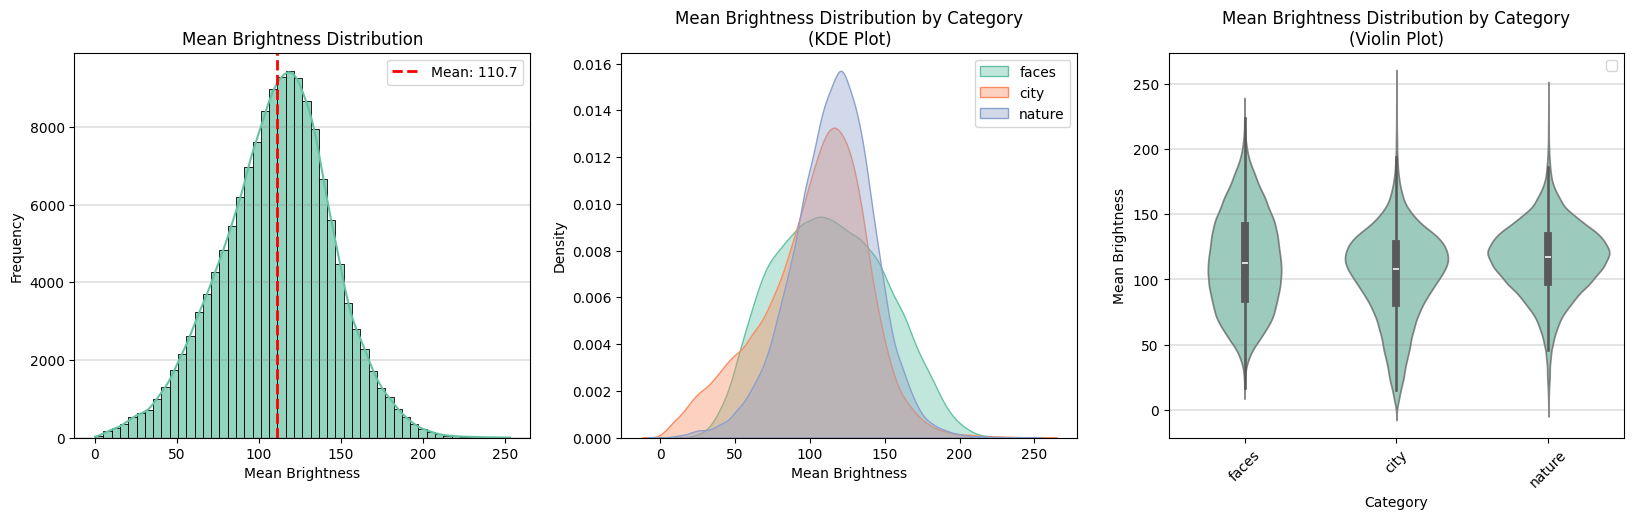

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(data=brightness_df, x='mean_brightness', bins=50, 
                kde=True, alpha=0.7, ax=axes[0])
axes[0].grid(axis='y', color='grey', linewidth=0.3)
axes[0].axvline(brightness_df['mean_brightness'].mean(), color='red', 
                linestyle='--', linewidth=2, 
                label=f'Mean: {brightness_df["mean_brightness"].mean():.1f}')
axes[0].set_xlabel('Mean Brightness')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Mean Brightness Distribution')
axes[0].legend()

for category in brightness_df['category'].unique():
    category_data = brightness_df[brightness_df['category'] == category]['mean_brightness']
    sns.kdeplot(data=category_data, label=category, ax=axes[1], fill=True, alpha=0.4)

axes[1].set_xlabel('Mean Brightness')
axes[1].set_ylabel('Density')
axes[1].set_title('Mean Brightness Distribution by Category\n(KDE Plot)')
axes[1].legend()

sns.violinplot(data=brightness_df, x='category', y='mean_brightness', 
                ax=axes[2], inner='box', alpha=0.7)


axes[2].grid(axis='y', color='grey', linewidth=0.3)
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Mean Brightness')
axes[2].set_title('Mean Brightness Distribution by Category\n(Violin Plot)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.show()


According to the plots the following conclusions were made:

1. The dataset brightness is balanced, the main part of the images does not require brightness modification before forwarding it to the model
2. The categories are not separated by illumination
3. The median brightness values among the categories are almost the same

Now let's find the outliers in the context of brightness:

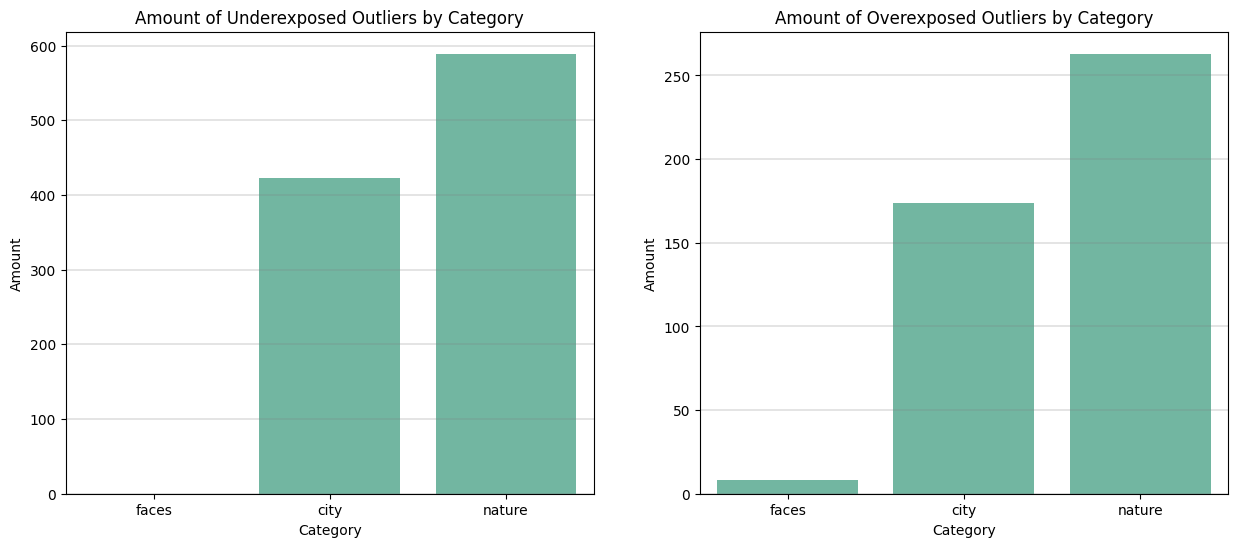

In [26]:
def detect_brightness_outliers(df, category):
    category_data = df[df['category'] == category]['mean_brightness']
    
    Q1 = category_data.quantile(0.25)
    Q3 = category_data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_outliers = category_data[category_data < (Q1 - 1.5 * IQR)]
    upper_outliers = category_data[category_data > (Q3 + 1.5 * IQR)]
    
    return len(lower_outliers), len(upper_outliers)

categories = brightness_df['category'].unique()
dark_outliers_count = []
bright_outliers_count = []

for category in categories:
    dark_count, bright_count = detect_brightness_outliers(brightness_df, category)
    dark_outliers_count.append(dark_count)
    bright_outliers_count.append(bright_count)

outliers_df = pd.DataFrame({
    'category': categories,
    'dark_outliers': dark_outliers_count,
    'bright_outliers': bright_outliers_count
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.grid(color='grey', linewidth=0.3)
sns.barplot(data=outliers_df, x='category', y='dark_outliers', ax=ax1)
ax1.set_title('Amount of Underexposed Outliers by Category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Amount')

ax2.grid(color='grey', linewidth=0.3)
sns.barplot(data=outliers_df, x='category', y='bright_outliers', ax=ax2)
ax2.set_title('Amount of Overexposed Outliers by Category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Amount')


plt.show()



`nature` and `city` have a significant (comparing to `faces`) number of underexposed and overexposed examples. 

The total amount of outliers:

In [33]:
print(outliers_df.drop('category', axis=1).values.sum())

1457


We leave these images unchanged. They will be used as edge cases for the model.

### **Conclusion**

* The initial number of images `150.000` was turned into `147.177` after removing the duplicates, the grayscale images, and the images with the `width/height` ratio more than `6`
* The images are well-splitable by `3` categories in terms of their features (based on applied ResNet and PCA)
* The `city` category images have variable resolutions that should be considered during transferring them to the model. On the other hand, the `nature` resolution is `512x512` and the `faces` resolution is `178x218`.
* The most `width/height` ratio of the images lies in `[1;2]`
* The dataset brightness is balanced, the main part of the images does not require brightness modification
